In [57]:
from data.download_data import download_dataset
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

from src.processed_data import processed_dataset


In [58]:
df1 = pd.read_csv("data/raw/train_identity.csv")

In [59]:
df1.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [60]:
df2 = pd.read_csv("data/raw/train_transaction.csv")

In [61]:
df2.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
df2.describe

<bound method NDFrame.describe of         TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             2987000        0          86400           68.50         W   
1             2987001        0          86401           29.00         W   
2             2987002        0          86469           59.00         W   
3             2987003        0          86499           50.00         W   
4             2987004        0          86506           50.00         H   
...               ...      ...            ...             ...       ...   
590535        3577535        0       15811047           49.00         W   
590536        3577536        0       15811049           39.50         W   
590537        3577537        0       15811079           30.95         W   
590538        3577538        0       15811088          117.00         W   
590539        3577539        0       15811131          279.95         W   

        card1  card2  card3       card4  card5  ... V330  V331  V

In [63]:
df1.isnull().sum().sum()

np.int64(2104107)

In [64]:
df2.isnull().sum().sum()

np.int64(95566686)

In [65]:
df = processed_dataset()
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [66]:
df.shape

(590540, 434)

In [67]:
df1.shape

(144233, 41)

In [68]:
df2.shape

(590540, 394)

In [69]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='str', length=434)

In [70]:
df['isFraud'].value_counts(normalize=True)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64

In [71]:
missing = df.isnull().sum().sort_values(ascending=False)
missing.head(20)

id_24    585793
id_25    585408
id_07    585385
id_08    585385
id_21    585381
id_26    585377
id_27    585371
id_23    585371
id_22    585371
dist2    552913
D7       551623
id_18    545427
D13      528588
D14      528353
D12      525823
id_04    524216
id_03    524216
D6       517353
id_33    517251
id_09    515614
dtype: int64

In [72]:
df.info

<bound method DataFrame.info of         TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             2987000        0          86400           68.50         W   
1             2987001        0          86401           29.00         W   
2             2987002        0          86469           59.00         W   
3             2987003        0          86499           50.00         W   
4             2987004        0          86506           50.00         H   
...               ...      ...            ...             ...       ...   
590535        3577535        0       15811047           49.00         W   
590536        3577536        0       15811049           39.50         W   
590537        3577537        0       15811079           30.95         W   
590538        3577538        0       15811088          117.00         W   
590539        3577539        0       15811131          279.95         W   

        card1  card2  card3       card4  card5  ...                

In [73]:
df.describe

<bound method NDFrame.describe of         TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  \
0             2987000        0          86400           68.50         W   
1             2987001        0          86401           29.00         W   
2             2987002        0          86469           59.00         W   
3             2987003        0          86499           50.00         W   
4             2987004        0          86506           50.00         H   
...               ...      ...            ...             ...       ...   
590535        3577535        0       15811047           49.00         W   
590536        3577536        0       15811049           39.50         W   
590537        3577537        0       15811079           30.95         W   
590538        3577538        0       15811088          117.00         W   
590539        3577539        0       15811131          279.95         W   

        card1  card2  card3       card4  card5  ...              

In [74]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='str', length=434)

In [75]:
df.shape

(590540, 434)

In [76]:
df.groupby('ProductCD')["isFraud"].mean()

ProductCD
C    0.116873
H    0.047662
R    0.037826
S    0.058996
W    0.020399
Name: isFraud, dtype: float64

In [77]:
df.isFraud.value_counts()

isFraud
0    569877
1     20663
Name: count, dtype: int64

<Axes: xlabel='isFraud'>

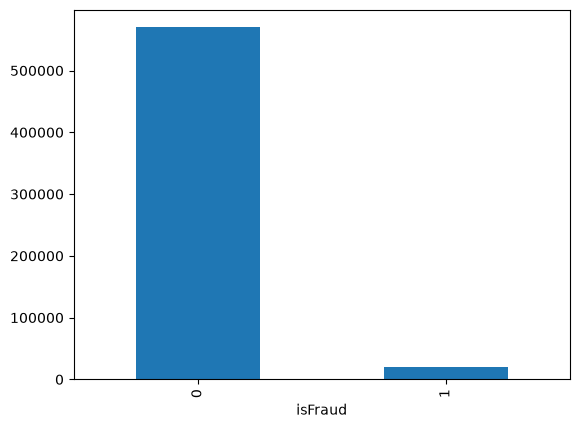

In [78]:
df.isFraud.value_counts().plot(kind="bar")

<BarContainer object of 2 artists>

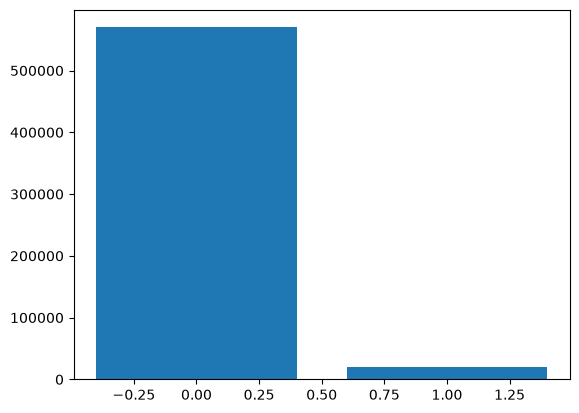

In [79]:
counts = df.isFraud.value_counts()

plt.bar(counts.index, counts.values)

(0.0, 500.0)

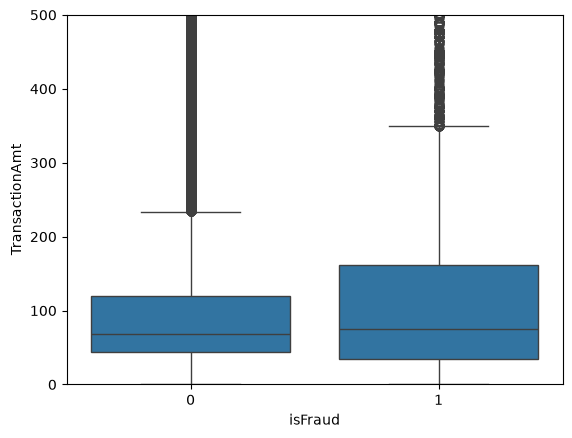

In [80]:
sns.boxplot(x='isFraud', y='TransactionAmt' ,data=df)
plt.ylim(0, 500)

In [81]:
import numpy as np

C:\Users\ASUS\AppData\Local\Temp\ipykernel_42252\4149351308.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["log_amt"] = np.log1p(df["TransactionAmt"])


<Axes: xlabel='isFraud', ylabel='log_amt'>

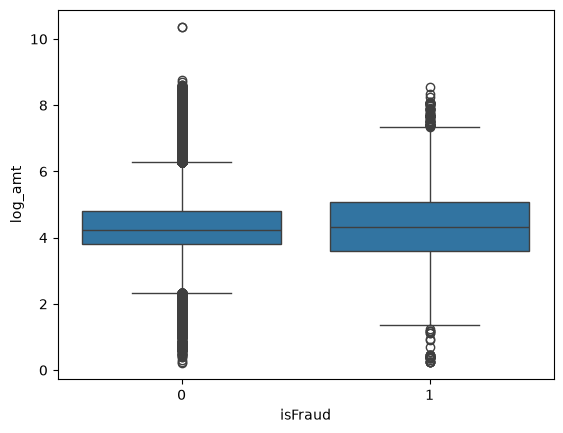

In [82]:
df["log_amt"] = np.log1p(df["TransactionAmt"])

sns.boxplot(x='isFraud', y='log_amt' ,data=df)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_42252\2675849298.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['missing_values'] = df.isnull().sum(axis=1)


<Axes: xlabel='isFraud', ylabel='missing_values'>

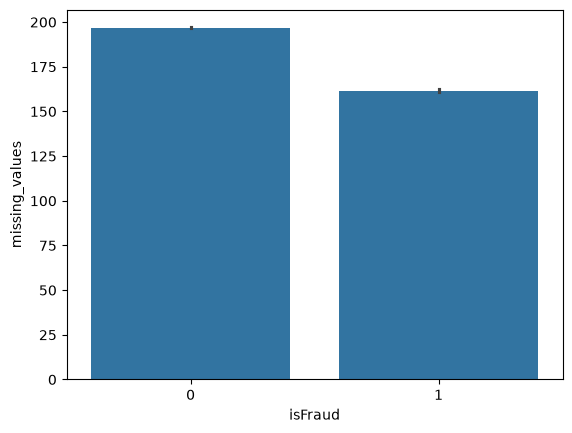

In [83]:
df['missing_values'] = df.isnull().sum(axis=1)

sns.barplot(x='isFraud', y='missing_values', data=df)

In [84]:
df[df['isFraud'] == 1]

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,log_amt,missing_values
203,2987203,1,89760,445.000,W,18268,583.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.100319,228
240,2987240,1,90193,37.098,C,13413,103.0,185.0,visa,137.0,...,NaN,NaN,F,F,T,T,mobile,Redmi Note 4 Build/MMB29M,3.640162,113
243,2987243,1,90246,37.098,C,13413,103.0,185.0,visa,137.0,...,NaN,NaN,F,F,T,T,mobile,Redmi Note 4 Build/MMB29M,3.640162,88
245,2987245,1,90295,37.098,C,13413,103.0,185.0,visa,137.0,...,NaN,NaN,F,F,T,T,mobile,Redmi Note 4 Build/MMB29M,3.640162,88
288,2987288,1,90986,155.521,C,16578,545.0,185.0,visa,226.0,...,NaN,NaN,F,F,F,F,mobile,NaN,5.053190,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590361,3577361,1,15807368,1224.000,W,3278,453.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.110696,208
590364,3577364,1,15807516,69.964,C,5812,408.0,185.0,mastercard,224.0,...,NaN,NaN,F,F,T,F,mobile,SAMSUNG SM-J700M Build/MMB29K,4.262173,92
590368,3577368,1,15807677,100.000,H,6758,399.0,150.0,american express,146.0,...,2208x1242,match_status:1,T,F,F,T,mobile,iOS Device,4.615121,180
590372,3577372,1,15807758,117.000,W,14037,111.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.770685,212


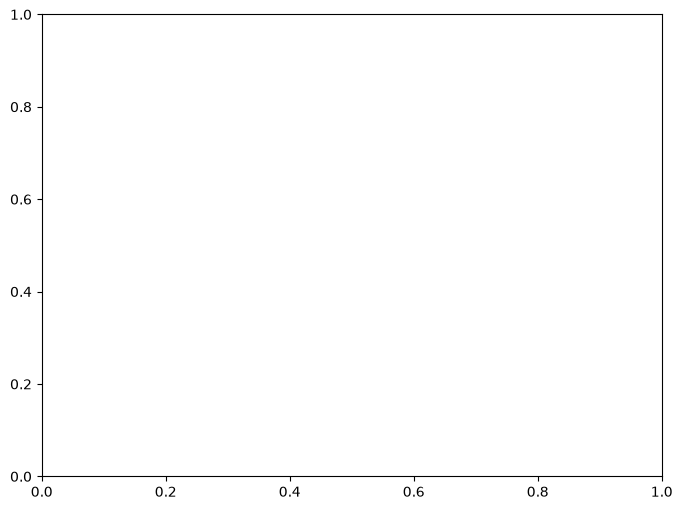

In [85]:
fig, ax = plt.subplots(figsize=(8, 6))



In [86]:
import numpy as np
df["log_TransactionAmt"] = np.log1p(df["TransactionAmt"])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_42252\477017875.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["log_TransactionAmt"] = np.log1p(df["TransactionAmt"])


In [87]:
df.columns

Index(['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt',
       'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5',
       ...
       'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo',
       'log_amt', 'missing_values', 'log_TransactionAmt'],
      dtype='str', length=437)

In [91]:
df['Hour'] = (df.TransactionDT // 3600) % 24
df["day"] = df["TransactionDT"] // (3600 * 24)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_42252\3797875400.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["day"] = df["TransactionDT"] // (3600 * 24)


In [99]:
path = 'data/processed_data/'
os.makedirs(path, exist_ok=True)

df.to_csv(os.path.join(path, 'processed_dataset.csv'), index=False)